# Machine Learning to Forecast Recessions
This notebook implements a complete pipeline for forecasting economic recessions using machine learning.
It includes data preprocessing, feature engineering, model training, evaluation, and interpretability.
Author: *Your Name Here*
Date: *Add Date Here*

In [ ]:
# Install required packages (for Google Colab)
!pip install scikit-learn xgboost imbalanced-learn shap

In [12]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Preprocess Data
We will load the cleaned CSV file and proceed with feature engineering.

In [13]:
# Load cleaned data
df = pd.read_csv("/content/Cleaned_Data_for_ML_Project.csv")
df.columns = ['Year', 'GDP Growth Rate (Annual)', 'Industrial Production Index', 'Unemployment Rate', 'CPI Annual', 'Yield Spread (10-year Treasury - Federal Funds Rate)', 'NBER Recession Indicators']
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['GDP Growth Rate (Annual)'] = pd.to_numeric(df['GDP Growth Rate (Annual)'], errors='coerce')
df['Industrial Production Index'] = pd.to_numeric(df['Industrial Production Index'], errors='coerce')
df['Unemployment Rate'] = pd.to_numeric(df['Unemployment Rate'], errors='coerce')
df['CPI Annual'] = pd.to_numeric(df['CPI Annual'], errors='coerce')
df['Yield Spread (10-year Treasury - Federal Funds Rate)'] = pd.to_numeric(df['Yield Spread (10-year Treasury - Federal Funds Rate)'], errors='coerce')
df['NBER Recession Indicators'] = pd.to_numeric(df['NBER Recession Indicators'], errors='coerce')
df.dropna(inplace=True)
df.head()

,Year,GDP Growth Rate (Annual),Industrial Production Index,Unemployment Rate,CPI Annual,Yield Spread (10-year Treasury - Federal Funds Rate),NBER Recession Indicators
0,1970.0,0.216606,39.4,132.88889,173.93089,17.33033,0.0
1,1971.0,3.292722,39.9,158.66667,181.28219,120.35076,0.0
2,1972.0,5.255502,43.8,149.33333,187.21546,143.27635,0.0
3,1973.0,5.645680,47.4,129.55556,198.93276,-149.68145,1.0
4,1974.0,-0.540550,47.2,150.44444,220.83738,-236.88450,1.0


## Feature Engineering
We will create lagged features and normalize the data.

In [14]:
# Create lagged features
lags = [1, 2, 4]
for col in df.columns:
    if col != 'NBER Recession Indicators' and col != 'Year':
        for lag in lags:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
df.dropna(inplace=True)

# Normalize features
X = df.drop(columns=['NBER Recession Indicators', 'Year'])
y = df['NBER Recession Indicators']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]  # Show first 5 rows of scaled features

array([[-1.60470253, -1.54703096, -0.3332136 , -1.74116123, -2.77367308,
         1.4220084 ,  1.18740427, -1.32359321, -1.47189635, -1.56072108,
        -1.59270122, -0.83926734, -0.41462945, -0.78218284, -1.75753909,
        -1.73762289, -1.64720693, -1.99547381,  0.40519346, -0.62442249],
       [-1.43771244, -1.73657385,  1.38908187, -1.67432823,  0.67837345,
        -1.59835018,  1.37516581,  0.26451632, -1.4808533 , -1.40102021,
        -1.57122467, -0.35443999, -0.88519818, -0.16225103, -1.68414516,
        -1.69799585, -1.6223287 , -2.71226645, -1.99896807,  0.21896055],
       [ 1.35117423, -1.58313437,  0.91798335, -1.62824928,  0.94259152,
        -1.43482382, -1.6017746 ,  1.27784249, -1.66894935, -1.40989248,
        -1.40370755,  1.39919168, -0.38819302, -0.38670924, -1.61650272,
        -1.62391603, -1.60224935,  0.67637799, -2.71460089,  0.4066423 ],
       [ 0.97033478, -1.42066904,  0.52286861, -1.57364634,  0.47952502,
         1.29621565, -1.44059895,  1.47927999, -

## Train-Test Split and SMOTE
We will split the data and handle class imbalance using SMOTE.

In [20]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE only to the training data
sm = SMOTE(random_state=42, k_neighbors=min(5, sum(y_train == 1) - 1))
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

## Train Models
We will train Logistic Regression, Random Forest, and XGBoost models.

In [21]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_resampled, y_train_resampled)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6)
rf_model.fit(X_train_resampled, y_train_resampled)

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6)
xgb_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

## Evaluate Models
We will evaluate models using precision, recall, AUC, and confusion matrix.

In [22]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

evaluate(rf_model, X_test, y_test)

[[9 0]
 [1 0]]
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95         9
         1.0       0.00      0.00      0.00         1

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10

AUC: 0.8888888888888888


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Feature Importance (Random Forest)

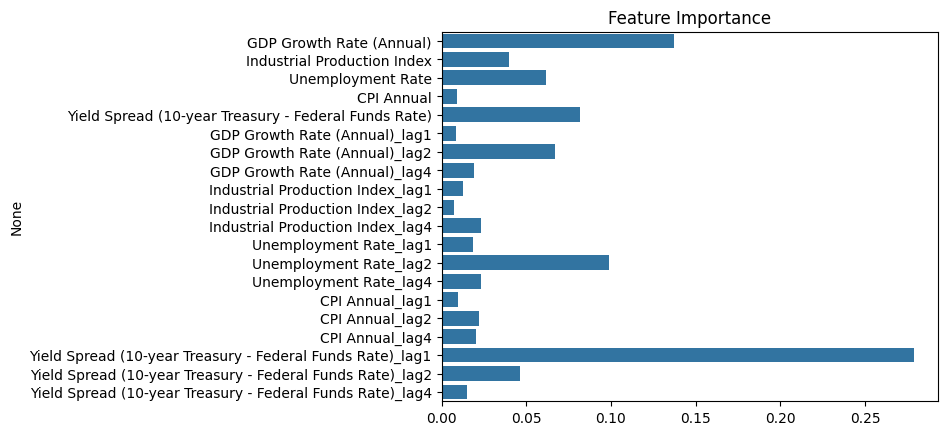

In [23]:
importances = rf_model.feature_importances_
features = X.columns
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

## SHAP Values for XGBoost

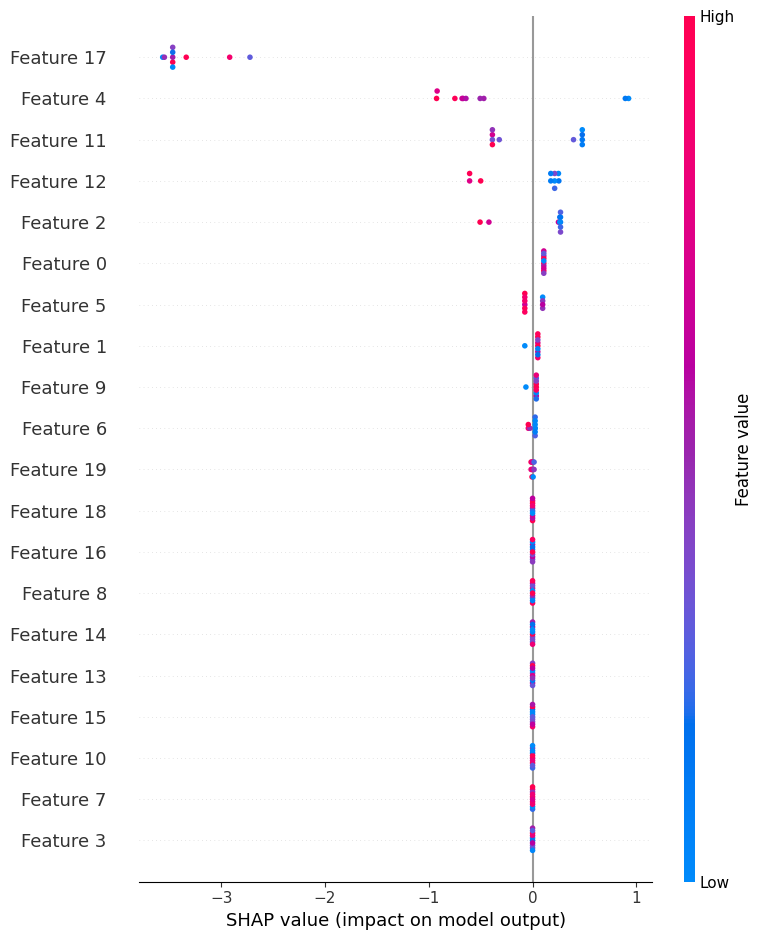

In [24]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)